# Прогнозирование курса акций Лукойл

---

In [2]:
# @title Libraries == LUKOIL ==
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D, MaxPooling1D, RepeatVector

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

2026-01-05 12:01:50.759721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767614511.164099      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767614511.275663      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767614512.264877      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767614512.264961      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767614512.264965      55 computation_placer.cc:177] computation placer alr

# Загрузка датасета и подготовка данных
Загрузим данные акций за 16-17 года и 18-19 года

In [6]:
# Чтение данных в таблицу pandas
file_path1 = '/kaggle/input/lukoil-16-17-18-19/16_17.csv' 
file_path2 = '/kaggle/input/lukoil-16-17-18-19/18_19.csv'
base_data = pd.read_csv(file_path, sep=';')
# Вывод первых строк таблицы
base_data.head()

,DATE,TIME,OPEN,MAX,MIN,CLOSE,VOLUME
0,03.01.2018,10:00:00,3341.0,3356.0,3340.0,3355.0,6088
1,03.01.2018,10:01:00,3355.0,3359.0,3353.0,3353.0,1624
2,03.01.2018,10:02:00,3351.5,3357.5,3351.5,3357.5,722
3,03.01.2018,10:03:00,3354.5,3360.0,3354.5,3358.0,3034
4,03.01.2018,10:04:00,3358.0,3360.0,3351.5,3360.0,1427


In [7]:
# Чтение данных в таблицы с удалением ненужных столбцов
data16_17 = pd.read_csv(file_path1 , sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv(file_path2 , sep=';').drop(columns=['DATE', 'TIME'])

In [8]:
# Проверка формы данных
data16_17.shape

(263925, 5)

In [9]:
# Пример данных одного датасета
d = data18_19

print(d.shape[0])                         # Всего записей (строк)
print(d.shape[1])                         # Количество столбцов
print(d.iloc[0])                          # Пример нулевой строки данных

217947
5
OPEN      3341.0
MAX       3356.0
MIN       3340.0
CLOSE     3355.0
VOLUME    6088.0
Name: 0, dtype: float64


In [10]:
# Создание общего набора данных из двух датасетов
data = pd.concat([data16_17, data18_19]).to_numpy()

In [11]:
# Проверка формы данных
print(data16_17.shape)
print(data18_19.shape)
print(data.shape)

(263925, 5)
(217947, 5)
(481872, 5)


In [12]:
# Задание текстовых меток каналов данных (столбцов)
CHANNEL_NAMES = ['Open', 'Max', 'Min', 'Close', 'Volume']

# Получение словаря с именами и индексами каналов данных
CHANNEL_INDEX = {name: chan for chan, name in enumerate(CHANNEL_NAMES)}
print(CHANNEL_INDEX)

{'Open': 0, 'Max': 1, 'Min': 2, 'Close': 3, 'Volume': 4}


# Иллюстрация данных в графическом виде

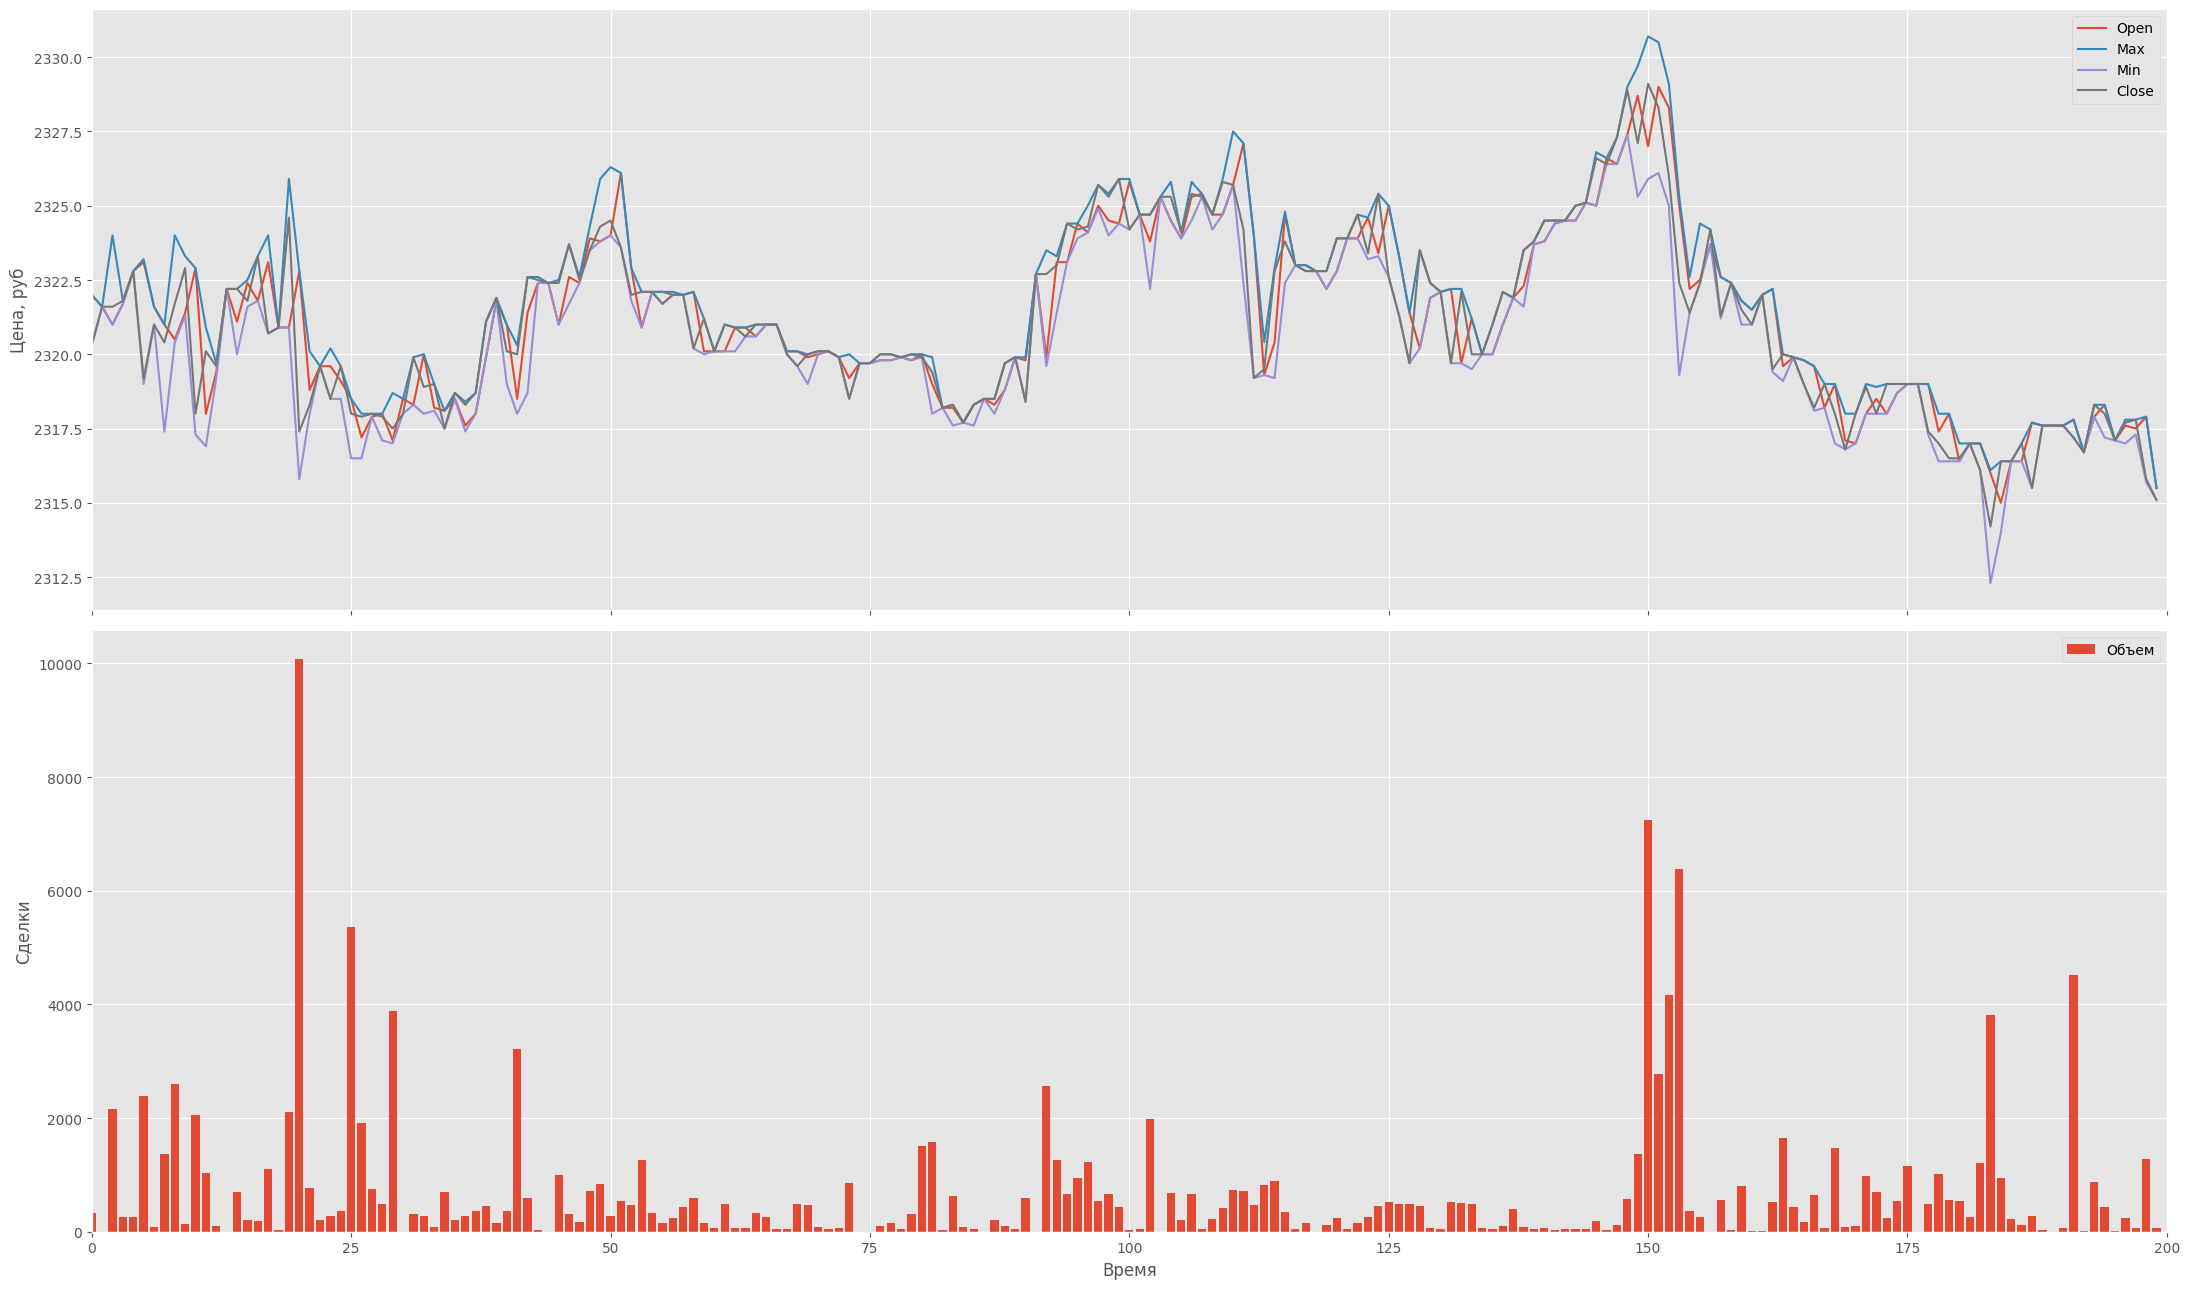

In [13]:
# Отображение исходных данных от точки start и длиной length
start = 100
length = 200

# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 13), sharex=True)

# Четыре основных канала - open, max, min, close
for chn in range(4):
    # Отрисовка одного канала данных
    # От начальной точки start длиной length
    ax1.plot(data[start:start + length, chn],
             label=CHANNEL_NAMES[chn])
ax1.set_ylabel('Цена, руб')
ax1.legend()

# Канал volume (объем)
ax2.bar(x=np.arange(length),
        height=data[start:start + length, CHANNEL_INDEX['Volume']],
        label='Объем')
ax2.set_ylabel('Сделки')
ax2.legend()

plt.xlabel('Время')
# Регулировка пределов оси x
plt.xlim(0, length)
# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()
# Фиксация графика
plt.show()

# Подготовка выборок данных для нейросети

In [14]:
# Словарь каналов данных с их индексами
print(CHANNEL_INDEX)

{'Open': 0, 'Max': 1, 'Min': 2, 'Close': 3, 'Volume': 4}


In [15]:
CHANNEL_NAMES

['Open', 'Max', 'Min', 'Close', 'Volume']

In [16]:
# Задание гиперпараметров

CHANNEL_X = CHANNEL_NAMES                 # Отбор каналов входных данных
CHANNEL_Y = ['Close']                     # Отбор каналов данных для предсказания
SEQ_LEN = 300                             # Длина прошедших данных для анализа
BATCH_SIZE = 20                           # Объем батча для генератора
TEST_LEN = 30_000                          # Объем тестовой выборки
TRAIN_LEN = data.shape[0] - TEST_LEN      # Объем обучающей выборки

In [17]:
print(data.shape[0])
TRAIN_LEN

481872


451872

In [18]:
# Формирование списков индексов каналов данных для входных и выходных выборок
chn_x = [CHANNEL_INDEX[c] for c in CHANNEL_X]
chn_y = [CHANNEL_INDEX[c] for c in CHANNEL_Y]

# Проверка результата
print(chn_x, chn_y)

[0, 1, 2, 3, 4] [3]


In [19]:
train_1 = data[:TRAIN_LEN].shape[0]
print('\033[94mTRAIN:\033[0m', train_1)

test_1 = data[TRAIN_LEN + 2+SEQ_LEN:].shape[0]
print('\033[95mTEST:\033[0m', test_1)

TRAIN: 451872
TEST: 29698


In [20]:
# Разделение данных на тренировочный и тестовый наборы
# 2+SEQ_LEN - для разрыва между тренировочными и тестовыми данными
# варьируемый параметр, страховка от пересечения
data_train, data_test = data[:TRAIN_LEN], data[TRAIN_LEN + (SEQ_LEN+2):]

# Отбор входных данных
x_data_train, x_data_test = data_train[:, chn_x], data_test[:, chn_x]

# Масштабирование данных
x_scaler = MinMaxScaler()
x_scaler.fit(x_data_train)
x_data_train = x_scaler.transform(x_data_train)
x_data_test = x_scaler.transform(x_data_test)

# Отбор выходных данных
y_data_train, y_data_test = data_train[:, chn_y], data_test[:, chn_y]

# Масштабирование данных
y_scaler = MinMaxScaler()
y_scaler.fit(y_data_train)
y_data_train = y_scaler.transform(y_data_train)
y_data_test = y_scaler.transform(y_data_test)

# Проверка формы данных
print(f'Train data: {x_data_train.shape}, {y_data_train.shape}')
print(f'Test  data: {x_data_test.shape}, {y_data_test.shape}')

# Создание генератора для обучения
train_datagen = TimeseriesGenerator(x_data_train,
                                    y_data_train,
                                    length=SEQ_LEN,
                                    stride=1,
                                    sampling_rate=1,
                                    batch_size=BATCH_SIZE)

# Аналогичный генератор для валидации при обучении
val_datagen = TimeseriesGenerator(x_data_test,
                                  y_data_test,
                                  length=SEQ_LEN,
                                  stride=1,
                                  sampling_rate=1,
                                  batch_size=BATCH_SIZE)

# Проверка формы выдаваемого генератором результата
print(f'Train batch x: {train_datagen[0][0].shape}, y: {train_datagen[0][1].shape}')

Train data: (451872, 5), (451872, 1)
Test  data: (29698, 5), (29698, 1)
Train batch x: (20, 300, 5), y: (20, 1)


In [21]:
# Генератор тестовой выборки, генерирует один батч на всю выборку
test_datagen = TimeseriesGenerator(x_data_test,
                                   y_data_test,
                                   length=SEQ_LEN,
                                   stride=1,
                                   sampling_rate=1,
                                   batch_size=x_data_test.shape[0])

# Формирование тестовой выборки из генератора
x_test, y_test = test_datagen[0]

# Проверка формы тестовой выборки
print(f'Test x: {x_test.shape}, y: {y_test.shape}')

Test x: (29398, 300, 5), y: (29398, 1)


# Сервисные функции


In [22]:
# Функция расчета результата прогнозирования сети (предсказания)

def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled

In [23]:
# Функция расчета корреляционного коэффициента Пирсона для двух рядов

def correlate(a, b):
    return np.corrcoef(a, b)[0, 1]

In [24]:
# Функция визуализации результата предсказания сети и верных ответов

def show_predict(y_pred, y_true, # прогноз данных и исходный ряд
                 start, # точка ряда, с которой начинается отрисовка графика
                 length, # количество точек для отрисовки графика
                 chn_list=None, # список каналов данных для отрисовки (по умолчанию все)
                 chn_names=CHANNEL_Y, # список имен каналов данных
                 title=''):

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    # Построение графика по всем каналам данных
    plt.figure(figsize=(22, 6))

    for chn in chn_list:
        plt.plot(y_pred[start:start + length, chn],
                label=f'{chn_names[chn]} Прогноз')
        plt.plot(y_true[start:start + length, chn],
                label=f'{chn_names[chn]} Базовый')

    plt.title(title)
    plt.xlabel('Время')
    plt.ylabel('Данные')
    plt.legend()
    plt.show()

In [25]:
# Функция рисования корреляций прогнозного ряда и исходного со смещением

def show_corr(y_pred, y_true, # прогноз данных и исходный ряд
              back_steps_max=30, # максимальное количество шагов смещения назад по времени
              chn_list=None, # список каналов данных для отрисовки (по умолчанию все)
              chn_names=CHANNEL_Y,
              title=''): # список имен каналов данных

    # Если список каналов пуст - отображаются все каналы
    if not chn_list:
        chn_list = list(range(y_true.shape[1]))

    y_len = y_true.shape[0]
    steps = range(0, back_steps_max + 1)

    # Построение графика по всем каналам данных
    plt.figure(figsize=(14, 7))

    for chn in chn_list:
        # Вычисление коэффициентов корреляции базового ряда и предсказания с разным смещением
        cross_corr = [correlate(y_true[:y_len - step, chn], y_pred[step:, chn]) for step in steps]
        # Вычисление коэффициентов автокорреляции базового ряда с разным смещением
        auto_corr = [correlate(y_true[:y_len - step, chn], y_true[step:, chn]) for step in steps]

        plt.plot(cross_corr, label=f'{chn_names[chn]} Прогноз')
        plt.plot(auto_corr, label=f'{chn_names[chn]} Эталон')

    plt.title(title)

    # Назначение меток шкалы оси x
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

In [26]:
# Функция визуализации результата работы сети

def eval_net(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler, # нормировщик выхода
             start=0, length=500, back_steps_max=30, # параметры отображения графиков
             title=''):

    # Получение денормализованного предсказания и данных базового ряда
    y_pred, y_true = get_pred(model, x_test, y_test, y_scaler)

    # Отрисовка графика сопоставления базового и прогнозного рядов
    # Прогнозный ряд сдвигается на 1 шаг назад, так как предсказание делалось на 1 шаг вперед
    show_predict(y_pred[1:], y_true[:-1], start, length,
                 title=f'{title}: Сопоставление базового и прогнозного рядов')
    # Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
    show_corr(y_pred, y_true, back_steps_max=back_steps_max,
              title=f'{title}: Корреляционные коэффициенты по шагам смещения')

In [27]:
# Функция обучения модели и отрисовки прогресса и оценки результатов

def train_eval_net(model, # модель
                   train_datagen, val_datagen, # генераторы обучающей и проверочной выборок
                   epoch_list, # список эпох в виде [(epochs1, opt1), (epochs2, opt2), ...]
                   x_test, y_test,
                   y_scaler,
                   start=0,
                   length=500,
                   back_steps_max=30,
                   title=''):

    # Отображение сводки модели
    model.summary()

    # Обучение модели в несколько фаз в соответствии со списком epoch_list
    for epochs, opt in epoch_list:
        # Компиляция модели
        model.compile(loss='mse', optimizer=opt)
        # Фаза обучения модели
        print(f'Обучение {epochs} эпох')
        history = model.fit(train_datagen,
                            epochs=epochs,
                            validation_data=val_datagen,
                            verbose=1)

        # Рисование графиков прошедшей фазы обучения
        fig = plt.figure(figsize=(14, 7))
        plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
        plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
        plt.title(f'{title}: График прогресса обучения')
        # Указание показывать только целые метки шкалы оси x
        fig.gca().xaxis.get_major_locator().set_params(integer=True)
        plt.xlabel('Эпоха обучения')
        plt.ylabel('Средняя ошибка')
        plt.legend()
        plt.show()

        # Рисование графиков оценки результата работы модели после фазы обучения
        eval_net(model, x_test, y_test, y_scaler, start=start,
                 length=length, back_steps_max=back_steps_max, title=title)

Далее пойдут эксперименты. Рассмотрим некоторые особенности:
- В train_eval_net() обучение запускается в цикле по списку эпох, который передается в функцию `epoch_list`. Так можно менять количество эпох и шаг обучения, не прописывая лишние строчки кода.
- Как видим, все архитектуры имеют склонность к автокорреляции и возможности роста результативности. Возможно, потребуется добавить обработку тренда.
- В целом задача предсказания точной цены закрытия акций не всегда логична. Чаще всего НС используют для предсказания, будет ли цена расти или падать в следующем периоде. Данную задачу мы рассмотрим в следующем блоке практической части урока.


# Полносвязная сеть
## Исследование №1

In [ ]:
# Простая полносвязная сеть
model_dense = Sequential()
model_dense.add(Dense(150, input_shape=x_test.shape[1:], activation='relu'))
model_dense.add(Flatten())
model_dense.add(Dense(y_test.shape[1], activation='linear'))

# Обучение модели 3x50 эпох
train_eval_net(model_dense, train_datagen, val_datagen, [(50, Adam(learning_rate=1e-4)),
                                                         (50, Adam(learning_rate=1e-5)),
                                                         (50, Adam(learning_rate=1e-6))],
               x_test, y_test, y_scaler, title='Полносвязная')

2026-01-05 12:21:02.063360: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300, 150)       │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 45000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        45,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,901 (179.30 KB)

 Trainable params: 45,901 (179.30 KB)

 Non-trainable params: 0 (0.00 B)

Обучение 50 эпох
Epoch 1/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 135s 6ms/step - loss: 0.0023 - val_loss: 8.6243e-05
Epoch 2/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 132s 6ms/step - loss: 1.3100e-04 - val_loss: 1.9453e-05
Epoch 3/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 132s 6ms/step - loss: 6.9240e-05 - val_loss: 1.7975e-05
Epoch 4/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 148s 7ms/step - loss: 3.7229e-05 - val_loss: 3.4095e-05
Epoch 5/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 153s 7ms/step - loss: 2.8401e-05 - val_loss: 9.1279e-05
Epoch 6/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 143s 6ms/step - loss: 2.4801e-05 - val_loss: 1.2411e-05
Epoch 7/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 142s 6ms/step - loss: 2.2509e-05 - val_loss: 1.8567e-05
Epoch 8/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 135s 6ms/step - loss: 1.9257e-05 - val_loss: 1.0626e-05
Epoch 9/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 132s 6ms/step - loss: 1.6174e-05 - val_loss: 4.7248e-05
Epoch 10/50
22579/22579 ━━━━━━━━━━━━━━━━━━━━ 145s 6ms/step - loss: 1.5589e-05 - val_los

Вывод: даже при небольшом наборе параметров и простоте архитектуры, сеть достаточно точно предсказывает значение, но это значение не является вполне корректным, так как график автокорреляции показывает, что график предсказания и реального значения имеют зависимость, т.е. нейронка предсказывает то, что было несколько шагов назад.

## Исследование №2

In [ ]:
# Полносвязная сеть с Flatten
model_dense_2 = Sequential()
model_dense_2.add(Flatten(input_shape=x_test.shape[1:]))
model_dense_2.add(Dense(150, activation='relu'))
model_dense_2.add(Dense(y_test.shape[1], activation='linear'))

# Обучение модели 2x20 эпох
train_eval_net(model_dense_2, train_datagen, val_datagen, [(20, Adam(learning_rate=1e-4)),
                                                           (20, Adam(learning_rate=1e-5))],
               x_test, y_test, y_scaler, title='Полносвязная №2')

Вывод: в этом случае мы сначала данные развернули в вектор и затем обрабатывали сетью. Так как мы ушли от исходной структуры данных, немного снизилась точность и увеличилась автокорреляция.
# Одномерная свёртка
## Исследование №1

In [ ]:
# Модель с одномерной сверткой
model_conv = Sequential()
model_conv.add(Conv1D(64, 5, input_shape=x_test.shape[1:], activation='relu'))
model_conv.add(Conv1D(64, 5, activation='relu'))
model_conv.add(MaxPooling1D())
model_conv.add(Flatten())
model_conv.add(Dense(100, activation='relu'))
model_conv.add(Dense(y_test.shape[1], activation='linear'))

# Обучение модели 50+20 эпох
train_eval_net(model_conv, train_datagen, val_datagen, [(50, Adam(learning_rate=1e-4)),
                                                        (20, Adam(learning_rate=1e-5))],
               x_test, y_test, y_scaler, title='Одномерная свертка')

**Вывод:** несмотря на то, что мы использовали сверточные слои и более сложную архитектуру, это не принесло результата, точность осталась почти на том же уровне. Но это не говорит о том, что свертки неэффективны для анализа временных рядов, стоит ещё поэкспериментировать с архитектурой.
## Исследование №2

In [ ]:
# Упрощенная модель с одномерной сверткой
model_conv_2 = Sequential()
model_conv_2.add(Conv1D(50, 5, input_shape=x_test.shape[1:], activation='linear'))
model_conv_2.add(Flatten())
model_conv_2.add(Dense(10, activation='linear'))
model_conv_2.add(Dense(y_test.shape[1], activation='linear'))

# Обучение модели 2x20 эпох
train_eval_net(model_conv_2, train_datagen, val_datagen, [(20, Adam(learning_rate=1e-4)),
                                                          (20, Adam(learning_rate=1e-5))],
               x_test, y_test, y_scaler, title='Одномерная свертка №2')

# Рекуррентная сеть (LSTM)

In [ ]:
model_lstm = Sequential()
model_lstm.add(LSTM(5, input_shape=x_test.shape[1:]))
model_lstm.add(Dense(10, activation='relu'))
model_lstm.add(Dense(y_test.shape[1], activation='linear'))

# Обучение модели 20 эпох
train_eval_net(model_lstm, train_datagen, val_datagen, [(20, Adam(learning_rate=1e-5))],
               x_test, y_test, y_scaler, title='Рекуррентная LSTM')